<a href="https://colab.research.google.com/github/vitor-pasqualotto/farmtech-fase6-visao-computacional/blob/main/VitorRodriguesPasqualotto_rm570440_pbl_fase6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FarmTech Solutions — Visão Computacional com YOLO (Fase 6)

| Nome | RM |
|---|---|
| Luiz Fernando Apolinário Azambuja | 572377 |
| João Paulo Sá Ribas Santos | 573805 |
| Davi Rocha Martins de Jesus | 568693 |
| Vitor Rodrigues Pasqualotto | 570440 |

## 1. Contexto
Demonstração para um cliente da FarmTech Solutions de como funciona, na prática,
um sistema de detecção de objetos. O modelo YOLOv5 foi customizado para reconhecer
dois objetos: **isqueiro** e **caixa de carregador**.

## 2. Dataset
- 80 imagens autorais (40 por objeto), fotografadas com variação de fundo, ângulo e iluminação.
- Divisão por objeto: 32 treino, 4 validação, 4 teste.
- Rotulagem feita no Make Sense AI, exportada em formato YOLO.
- Classes: `0 = isqueiro`, `1 = carregador`.

## 3. Conexão com o Google Drive e verificação do dataset

In [ ]:
# Conecta o Colab ao Google Drive, onde estão as imagens e os rótulos
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

# Caminho da pasta do dataset no Drive
BASE = Path('/content/drive/MyDrive/FIAP/Trabalhos/Fase 6 - Cap 1/dataset')

for split in ['train', 'val', 'test']:
    # Nomes (sem extensão) das imagens e dos rótulos de cada divisão
    imgs = {p.stem for p in (BASE / 'images' / split).iterdir()
            if p.suffix.lower() in ['.jpg', '.jpeg', '.png']}
    lbls = {p.stem for p in (BASE / 'labels' / split).glob('*.txt')}
    print(f'{split}: {len(imgs)} imagens, {len(lbls)} rótulos')

    # Aponta imagens sem rótulo e rótulos sem imagem
    if imgs - lbls:
        print('  sem rótulo:', sorted(imgs - lbls))
    if lbls - imgs:
        print('  rótulo sem imagem:', sorted(lbls - imgs))

    # Confere se a classe gravada bate com o nome do arquivo
    for f in (BASE / 'labels' / split).glob('*.txt'):
        classes = {linha.split()[0] for linha in f.read_text().splitlines() if linha.strip()}
        esperado = '0' if f.stem.startswith('isqueiro') else '1'
        if classes != {esperado}:
            print(f'  classe inesperada em {f.name}: {classes}')

train: 64 imagens, 64 rótulos
val: 8 imagens, 8 rótulos
test: 8 imagens, 8 rótulos


In [ ]:
# Baixa o YOLOv5 e instala as dependências
%cd /content
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -qr requirements.txt

/content
Cloning into 'yolov5'...
remote: Enumerating objects: 18770, done.
remote: Counting objects: 100% (326/326), done.
remote: Compressing objects: 100% (194/194), done.
remote: Total 18770 (delta 264), reused 132 (delta 132), pack-reused 18444 (from 5)
Receiving objects: 100% (18770/18770), 17.79 MiB | 19.19 MiB/s, done.
Resolving deltas: 100% (12768/12768), done.
/content/yolov5
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 10.8 MB/s eta 0:00:00


In [ ]:
# Arquivo de configuração que diz ao YOLO onde estão os dados e quais são as classes
config = f"""path: {BASE}
train: images/train
val: images/val
test: images/test
nc: 2
names: ['isqueiro', 'carregador']
"""
with open('/content/farmtech.yaml', 'w') as f:
    f.write(config)
print(config)

path: /content/drive/MyDrive/FIAP/Trabalhos/Fase 6 - Cap 1/dataset
train: images/train
val: images/val
test: images/test
nc: 2
names: ['isqueiro', 'carregador']



## 4. Treinamento — Simulação 1 (30 épocas)

Treino do YOLOv5s partindo dos pesos pré-treinados (`yolov5s.pt`), ajustados
para as duas classes do dataset. Parâmetros:
- `--img 640`: imagens redimensionadas para 640 px;
- `--batch 16`: 16 imagens por lote;
- `--epochs 30`: número de passagens completas pelo conjunto de treino;
- `--cache`: carrega as imagens em memória para acelerar o treino.

A validação é executada automaticamente ao final de cada época,
usando as 8 imagens da pasta `val`.

In [ ]:
import time

%cd /content/yolov5

# Marca o início para medir o tempo total de treino
inicio = time.time()

# Treina o YOLOv5s por 30 épocas com o dataset customizado
!python train.py --img 640 --batch 16 --epochs 30 \
    --data /content/farmtech.yaml --weights yolov5s.pt \
    --name farmtech_30ep --exist-ok --cache

# Guarda o tempo de treino para a comparação posterior
tempo_30 = time.time() - inicio
print(f'Tempo de treino (30 épocas): {tempo_30 / 60:.1f} min')

/content/yolov5
WARNING ⚠️ wandb: wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
I0000 00:00:1791387293.857429   22268 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: WARNING W&B disabled due to login timeout.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train: weights=yolov5s.pt, cfg=, data=/content/farmtech.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=30, batch_size=16, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data/hyps, resume_evolve=None, bucket=, cache=ram, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, p

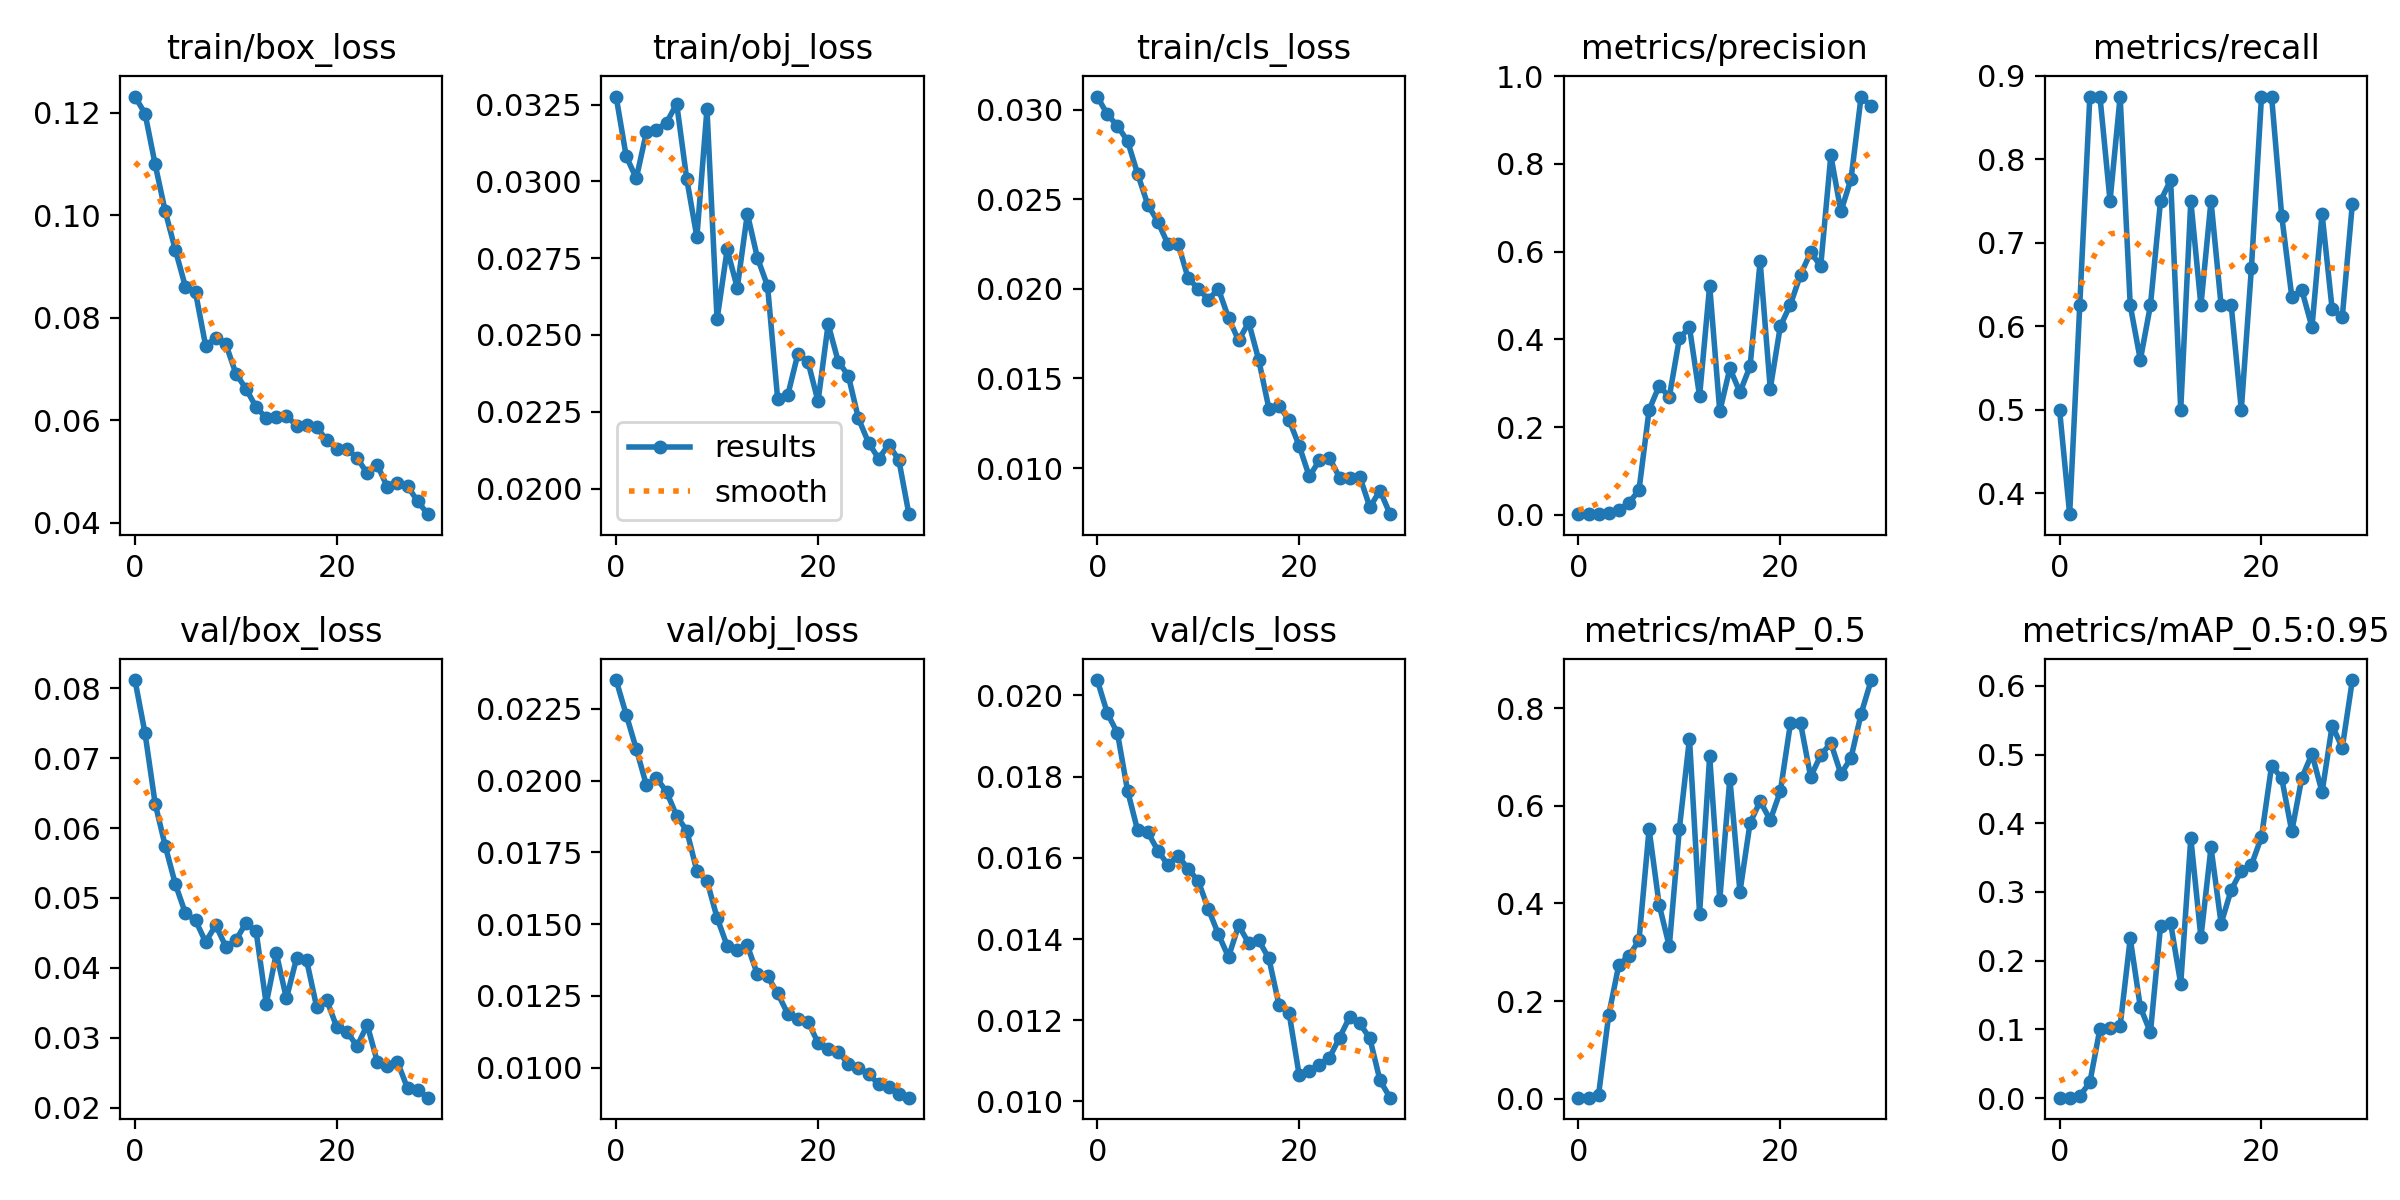

,metrics/precision,metrics/recall,metrics/mAP_0.5,metrics/mAP_0.5:0.95,val/box_loss,val/obj_loss,val/cls_loss
29,0.9314,0.74664,0.8572,0.6084,0.021409,0.008949,0.010092


In [ ]:
import pandas as pd
from IPython.display import Image, display

# Curvas de erro (loss) e métricas ao longo das épocas
display(Image('runs/train/farmtech_30ep/results.png', width=900))

# Métricas da última época
r30 = pd.read_csv('runs/train/farmtech_30ep/results.csv')
r30.columns = r30.columns.str.strip()
colunas = ['metrics/precision', 'metrics/recall', 'metrics/mAP_0.5',
           'metrics/mAP_0.5:0.95', 'val/box_loss', 'val/obj_loss', 'val/cls_loss']
r30[colunas].tail(1)

### Análise da Simulação 1 (30 épocas)

| Métrica | Valor |
|---|---|
| Precisão | 0,931 |
| Recall | 0,747 |
| `mAP@0.5` | 0,857 |
| `mAP@0.5:0.95` | 0,608 |

- **Erro:** as três perdas (box, obj e cls) caem de forma contínua em treino e em
  validação, sem a validação voltar a subir. Não há sinal de overfitting.
- **Convergência:** as curvas ainda estão em queda na última época e as métricas
  ainda sobem, o que indica que 30 épocas não foram suficientes para o modelo
  estabilizar.
- **Oscilação:** precisão e recall variam bastante entre épocas porque a validação
  tem apenas 8 imagens, então um único erro altera muito o resultado.
- **Leitura prática:** o modelo erra pouco quando detecta (precisão de 0,93), mas
  ainda deixa de detectar 1 em cada 4 objetos (recall de 0,75).

## 5. Treinamento — Simulação 2 (60 épocas)

Mesma configuração da simulação anterior, alterando apenas o número de épocas,
para medir o efeito desse parâmetro em acurácia, erro e tempo de treino.

In [ ]:
%cd /content/yolov5

# Marca o início para medir o tempo total de treino
inicio = time.time()

# Treina o YOLOv5s por 60 épocas, mantendo os demais parâmetros
!python train.py --img 640 --batch 16 --epochs 60 \
    --data /content/farmtech.yaml --weights yolov5s.pt \
    --name farmtech_60ep --exist-ok --cache

# Guarda o tempo de treino para a comparação posterior
tempo_60 = time.time() - inicio
print(f'Tempo de treino (60 épocas): {tempo_60 / 60:.1f} min')

/content/yolov5
WARNING ⚠️ wandb: wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
I0000 00:00:1791387427.547400   22922 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: WARNING W&B disabled due to login timeout.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train: weights=yolov5s.pt, cfg=, data=/content/farmtech.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=60, batch_size=16, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data/hyps, resume_evolve=None, bucket=, cache=ram, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, p

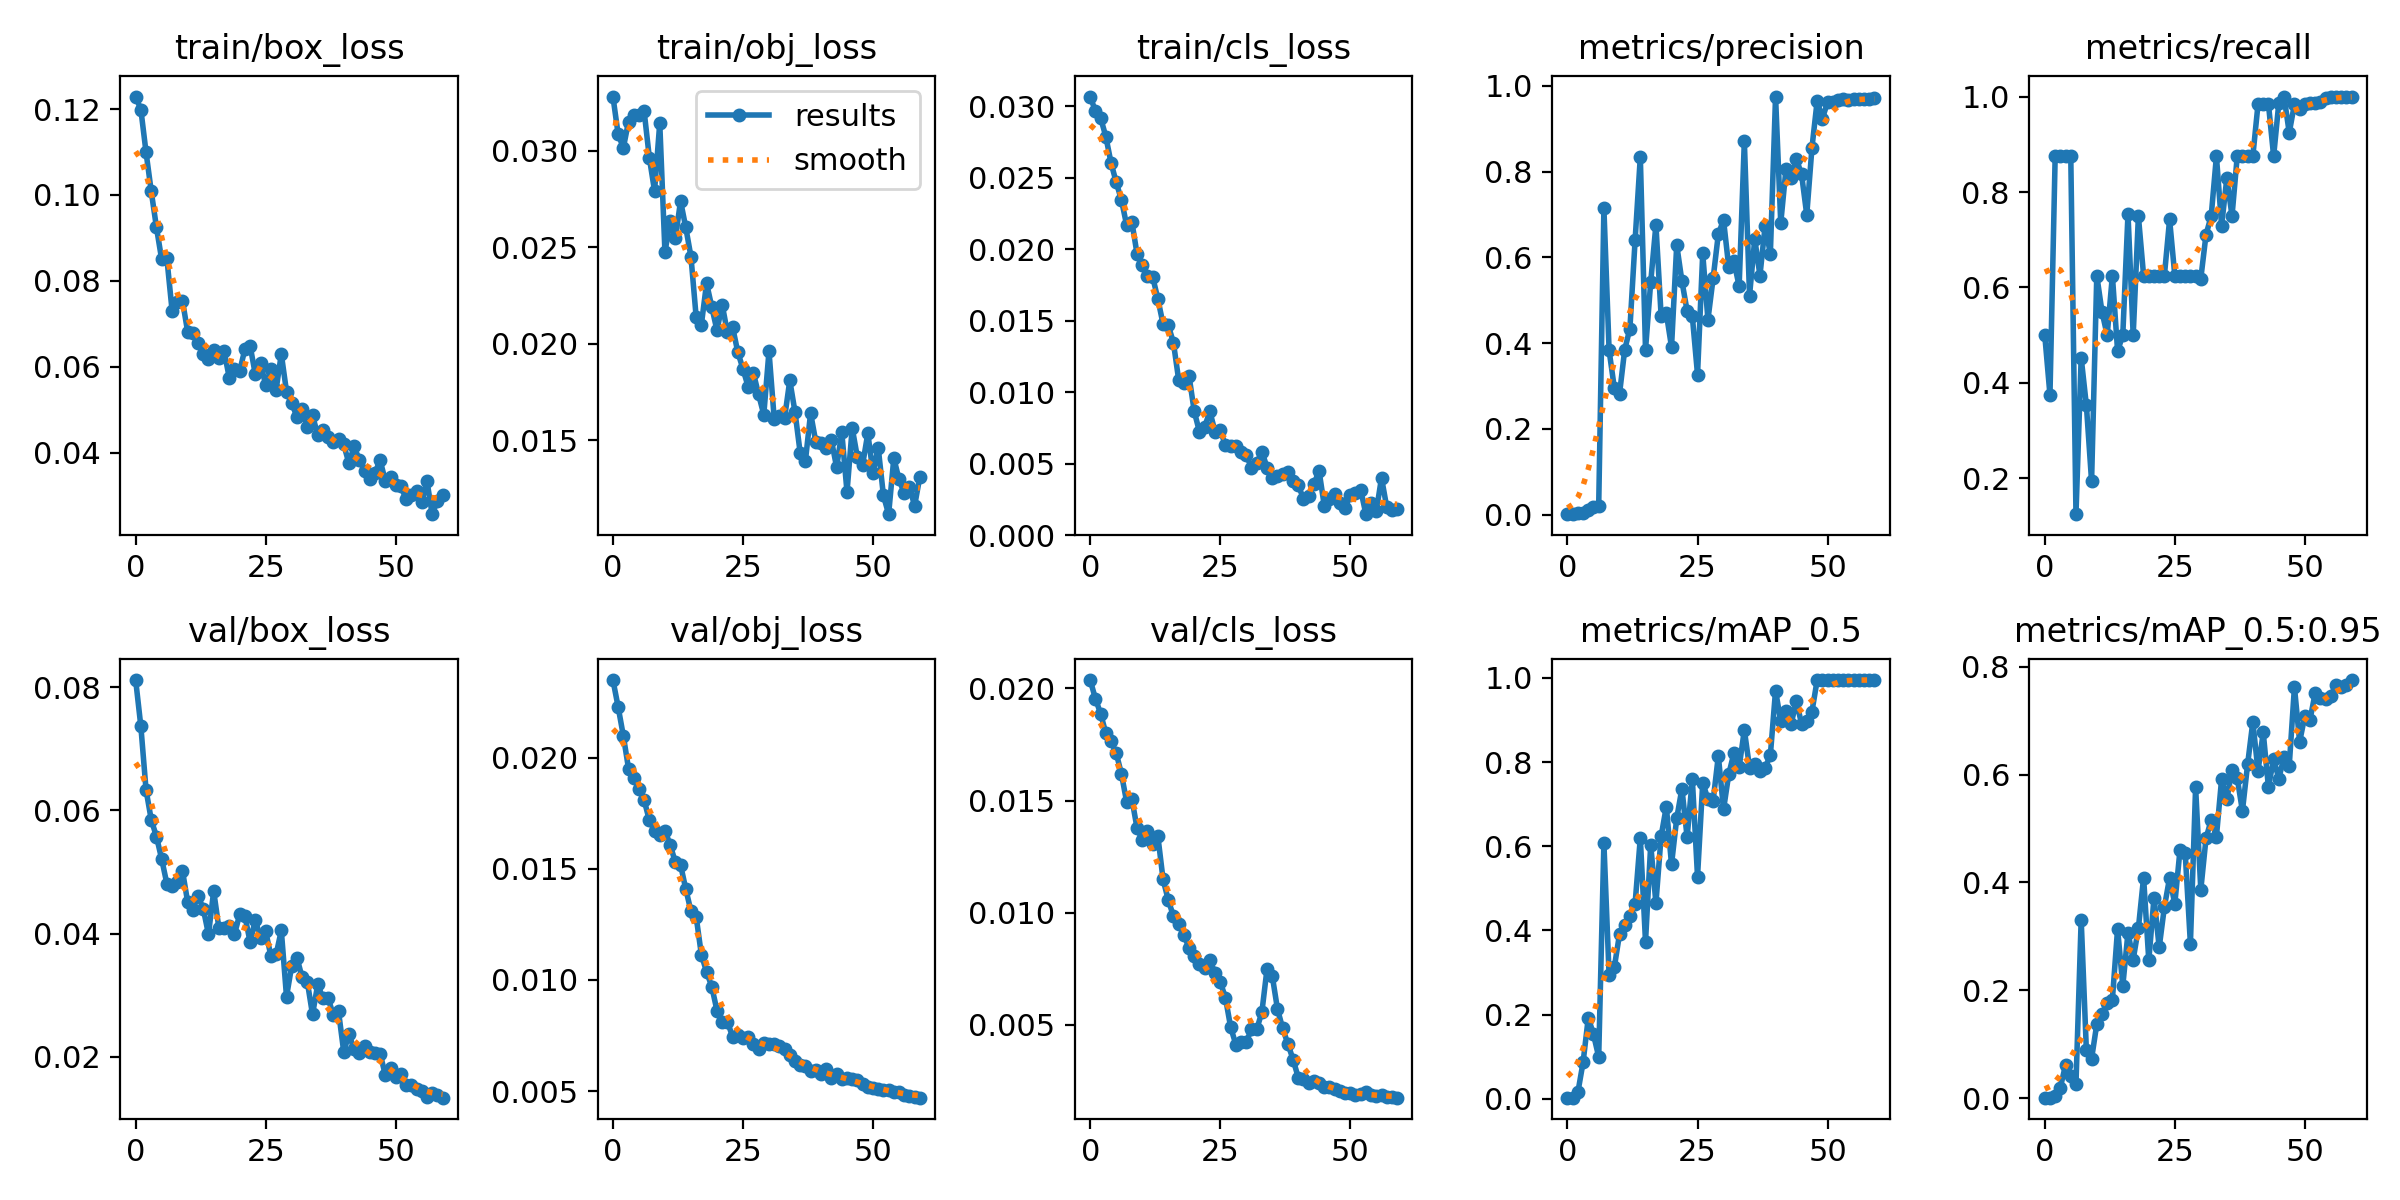

,metrics/precision,metrics/recall,metrics/mAP_0.5,metrics/mAP_0.5:0.95,val/box_loss,val/obj_loss,val/cls_loss
59,0.97047,1.0,0.995,0.77548,0.01337,0.004702,0.001748


In [ ]:
# Curvas de erro (loss) e métricas ao longo das épocas
display(Image('runs/train/farmtech_60ep/results.png', width=900))

# Métricas da última época
r60 = pd.read_csv('runs/train/farmtech_60ep/results.csv')
r60.columns = r60.columns.str.strip()
r60[colunas].tail(1)

## 6. Comparação: 30 x 60 épocas

,30 épocas,60 épocas,variação
metrics/precision,0.931,0.970,0.039
metrics/recall,0.747,1.000,0.253
metrics/mAP_0.5,0.857,0.995,0.138
metrics/mAP_0.5:0.95,0.608,0.775,0.167
val/box_loss,0.021,0.013,-0.008
val/obj_loss,0.009,0.005,-0.004
val/cls_loss,0.010,0.002,-0.008
tempo de treino (min),2.255,3.067,0.812


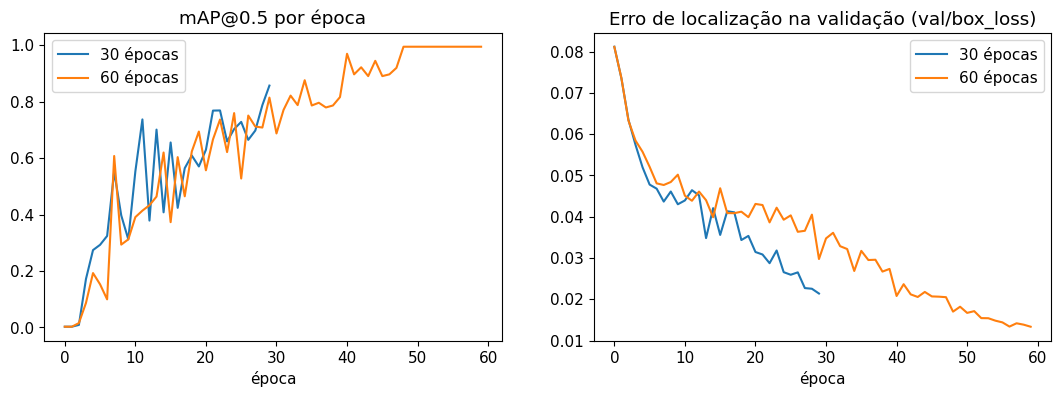

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

# Tabela comparativa com as métricas da última época de cada treino
comp = pd.DataFrame({
    '30 épocas': r30[colunas].iloc[-1],
    '60 épocas': r60[colunas].iloc[-1],
})
comp.loc['tempo de treino (min)'] = [tempo_30 / 60, tempo_60 / 60]
comp['variação'] = comp['60 épocas'] - comp['30 épocas']
display(comp.round(3))

# Evolução da acurácia (mAP@0.5) e do erro de validação nos dois treinos
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for nome, r in [('30 épocas', r30), ('60 épocas', r60)]:
    ax[0].plot(r['metrics/mAP_0.5'], label=nome)
    ax[1].plot(r['val/box_loss'], label=nome)
ax[0].set_title('mAP@0.5 por época')
ax[1].set_title('Erro de localização na validação (val/box_loss)')
for a in ax:
    a.set_xlabel('época')
    a.legend()
plt.show()

### Conclusões da comparação

- **Acurácia:** com 60 épocas o modelo passou a encontrar todos os objetos da
  validação (recall de 0,75 para 1,00), mantendo precisão alta (0,93 para 0,97).
  O `mAP@0.5` subiu de 0,857 para 0,995.
- **Erro:** as três perdas de validação caíram: localização de 0,021 para 0,013,
  objetividade de 0,009 para 0,005 e classificação de 0,010 para 0,002, quase
  seis vezes menor. A perda de classificação teve uma oscilação pontual perto da
  época 35, mas retomou a queda e terminou no menor valor, então o treino mais
  longo não causou overfitting.
- **Desempenho:** o tempo passou de 2 min 15 s para 3 min 04 s, aumento de 36%.
  Não chega a dobrar porque parte do tempo é fixa (inicialização, carga das
  imagens e validação final). O custo extra é pequeno diante do ganho de acurácia.
- **Ajuste das caixas:** o `mAP@0.5:0.95` subiu de 0,608 para 0,775. É a métrica
  mais exigente e a que mais tem espaço para melhorar: o modelo acerta qual é o
  objeto e onde ele está, mas as caixas ainda não ficam perfeitamente ajustadas.
- **Ressalva:** a validação tem apenas 8 imagens, então esses números têm alta
  variância. A confirmação vem do conjunto de teste, na próxima seção.

**Modelo escolhido:** o de 60 épocas.

## 7. Teste com imagens inéditas

As 8 imagens da pasta `test` não participaram do treino nem da validação.
Primeiro são calculadas as métricas dos dois modelos nesse conjunto; depois, o
modelo escolhido (60 épocas) processa as imagens e desenha as detecções.

In [ ]:
%cd /content/yolov5

# Métricas do modelo de 30 épocas no conjunto de teste
!python val.py --weights runs/train/farmtech_30ep/weights/best.pt \
    --data /content/farmtech.yaml --img 640 --task test --name test_30ep --exist-ok

# Métricas do modelo de 60 épocas no conjunto de teste
!python val.py --weights runs/train/farmtech_60ep/weights/best.pt \
    --data /content/farmtech.yaml --img 640 --task test --name test_60ep --exist-ok

/content/yolov5
val: data=/content/farmtech.yaml, weights=['runs/train/farmtech_30ep/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=test_30ep, exist_ok=True, half=False, dnn=False
YOLOv5 🚀 v7.0-556-gf9578796 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 68 layers, 7,015,519 parameters, 0 gradients, 15.8 GFLOPs
test: Scanning /content/drive/MyDrive/FIAP/Trabalhos/Fase 6 - Cap 1/dataset/labels/test... 8 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8/8 1.9s/it 15.6s
test: WARNING ⚠️ /content/drive/MyDrive/FIAP/Trabalhos/Fase 6 - Cap 1/dataset/images/test/carregador_10.jpg: corrupt JPEG restored and saved
test: WARNING ⚠️ /content/drive/MyDrive/FIAP/Trabalhos/Fase 6 - Cap 1/dataset/images/test/carregador_20.jpg: corrupt JP

In [ ]:
# Detecção nas imagens de teste com o modelo de 60 épocas
# (--conf 0.25: só mostra detecções com confiança de pelo menos 25%)
# (--line-thickness 10: caixas e rótulos mais grossos, legíveis em fotos grandes)
!python detect.py --weights runs/train/farmtech_60ep/weights/best.pt \
    --source "{BASE}/images/test" --img 640 --conf 0.25 \
    --line-thickness 10 --name test_60ep --exist-ok

detect: weights=['runs/train/farmtech_60ep/weights/best.pt'], source=/content/drive/MyDrive/FIAP/Trabalhos/Fase 6 - Cap 1/dataset/images/test, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, update=False, project=runs/detect, name=test_60ep, exist_ok=True, line_thickness=10, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-556-gf9578796 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 68 layers, 7,015,519 parameters, 0 gradients, 15.8 GFLOPs
image 1/8 /content/drive/MyDrive/FIAP/Trabalhos/Fase 6 - Cap 1/dataset/images/test/carregador_10.jpg: 640x480 1 carregador, 28.2ms
image 2/8 /content/drive/MyDrive/FIAP/Trabalhos/Fase 6 - Cap 1/dataset/images/test/carregador_20.jpg: 640x480 1 carregador, 13.2m

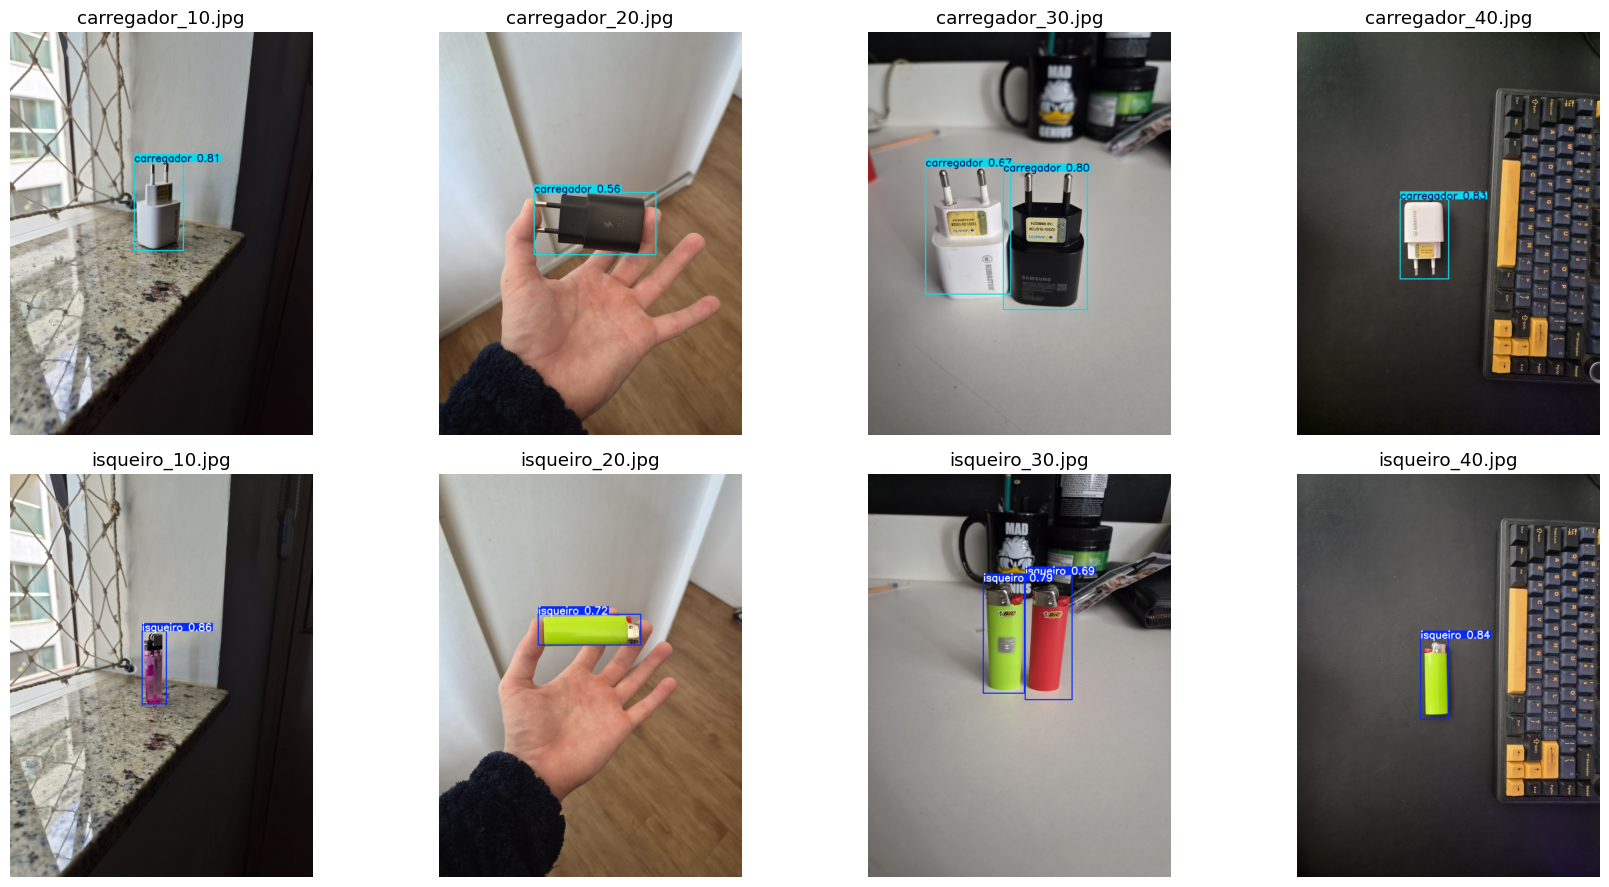

In [ ]:
# Mostra as 8 imagens de teste com as caixas e a confiança de cada detecção
resultados = sorted(Path('runs/detect/test_60ep').glob('*.*'))

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, caminho in zip(axes.ravel(), resultados):
    ax.imshow(plt.imread(caminho))
    ax.set_title(caminho.name)
    ax.axis('off')
plt.tight_layout()
plt.show()

### Análise do teste

| Modelo | Precisão | Recall | `mAP@0.5` | `mAP@0.5:0.95` | Inferência |
|---|---|---|---|---|---|
| 30 épocas | 0,992 | 0,999 | 0,995 | 0,762 | 18,5 ms |
| 60 épocas | 0,934 | 0,989 | 0,995 | 0,778 | 14,4 ms |

- **Detecção:** o modelo de 60 épocas localizou os 10 objetos presentes nas 8
  imagens (5 isqueiros e 5 carregadores), incluindo as duas imagens com dois
  objetos, sem trocar as classes e sem detecções a mais.
- **30 x 60 épocas:** no teste, os dois modelos ficaram equivalentes, com o mesmo
  `mAP@0.5` (0,995). O de 60 épocas ajusta um pouco melhor as caixas
  (`mAP@0.5:0.95` de 0,778 contra 0,762) e o de 30 teve precisão maior (0,992
  contra 0,934, diferença concentrada na classe isqueiro). Com apenas 10 objetos,
  diferenças desse tamanho estão dentro da margem de variação.
- **Validação x teste:** a grande vantagem do modelo de 60 épocas na validação
  (recall de 1,00 contra 0,75) não se repetiu no teste. Parte daquela diferença
  vinha do tamanho reduzido do conjunto de validação, e não só do número de
  épocas. A conclusão segura é que 60 épocas não pioram o modelo e melhoram o
  ajuste das caixas; a superioridade em acurácia não fica comprovada com 8
  imagens de teste.
- **Velocidade:** a inferência leva de 14 a 18 ms por imagem na GPU T4, o que
  equivale a mais de 50 imagens por segundo, suficiente para uso em tempo real.
  A diferença de tempo entre os dois modelos é ruído de medição, já que a
  arquitetura é a mesma.

## 8. Conclusões da Entrega 1

**Para o cliente:** com 64 fotos de treino e cerca de 3 minutos de processamento,
o sistema aprendeu a localizar e identificar dois objetos que não conhecia. Nas 8
imagens de teste, nunca vistas pelo modelo, ele encontrou os 10 objetos presentes
sem confundir as classes, em menos de 20 ms por imagem.

### Pontos fortes
- **Pouco dado, bom resultado:** partir de pesos pré-treinados (`yolov5s.pt`)
  permitiu chegar a `mAP@0.5` de 0,995 com apenas 32 imagens de treino por classe.
- **Custo baixo:** o treino completo de 60 épocas leva cerca de 3 minutos em uma
  GPU gratuita do Colab.
- **Velocidade:** a inferência é rápida o suficiente para vídeo em tempo real.
- **Processo reproduzível:** dataset autoral, rotulagem, treino, validação e teste
  estão documentados e executados neste notebook, com os resultados salvos em
  `runs/train/`, `runs/val/` e `runs/detect/`.

### Limitações
- **Conjuntos de validação e teste pequenos:** com 8 imagens cada, um único erro
  muda muito as métricas. Isso ficou evidente na diferença entre os dois modelos,
  grande na validação e inexistente no teste.
- **Variação entre execuções:** o treino tem componentes aleatórios, e repetir a
  mesma configuração produz métricas diferentes. Com tão poucos dados de
  avaliação, essa variação é comparável ao efeito de dobrar as épocas.
- **Pouca diversidade de objetos e cenários:** as fotos foram feitas com poucos
  exemplares de cada objeto e nos mesmos ambientes do treino. O teste mede se o
  modelo reconhece esses objetos nesses cenários, não se generaliza para outros
  modelos de isqueiro ou carregador, ou para outros locais.
- **Sem imagens negativas:** o dataset não tem fotos sem nenhum dos objetos, então
  não foi medido o risco de falso alarme em cenas vazias ou com objetos parecidos.
- **Classes sempre separadas:** nenhuma imagem contém isqueiro e carregador
  juntos, situação que não foi avaliada.
- **Ajuste das caixas:** o `mAP@0.5:0.95` de 0,78 mostra que a localização ainda
  não é precisa no nível do pixel.

### Próximos passos
Ampliar o dataset com mais exemplares e ambientes, incluir imagens sem objetos,
aumentar os conjuntos de validação e teste e repetir o treino mais de uma vez para
medir a variação dos resultados.

# Entrega 2 — Comparação entre abordagens

Três abordagens são comparadas sobre a mesma base de imagens:
1. **YOLO customizado** (Entrega 1): YOLOv5s ajustado para as classes do dataset;
2. **YOLO padrão:** YOLOv5s original, sem nenhum treino adicional;
3. **CNN treinada do zero:** rede de classificação definida e treinada neste notebook.

Critérios: facilidade de uso e integração, precisão, tempo de treinamento e
tempo de inferência.

## 9. YOLO padrão (sem customização)

O `yolov5s.pt` original foi treinado no dataset COCO e reconhece 80 classes de
objetos do cotidiano. Nem isqueiro nem carregador estão entre elas. A hipótese é
que ele não consiga identificar os objetos, ou os confunda com classes parecidas
que conhece.

In [ ]:
import matplotlib.pyplot as plt

%cd /content/yolov5

# Detecção nas mesmas imagens de teste com o YOLOv5s original (80 classes do COCO)
!python detect.py --weights yolov5s.pt \
    --source "{BASE}/images/test" --img 640 --conf 0.25 \
    --line-thickness 10 --name test_padrao --exist-ok

/content/yolov5
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
detect: weights=['yolov5s.pt'], source=/content/drive/MyDrive/FIAP/Trabalhos/Fase 6 - Cap 1/dataset/images/test, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, update=False, project=runs/detect, name=test_padrao, exist_ok=True, line_thickness=10, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-556-gf9578796 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)

100% 14.1M/14.1M [00:00<00:00, 96.9MB/s]

Fusing layers... 
YOLOv5s su

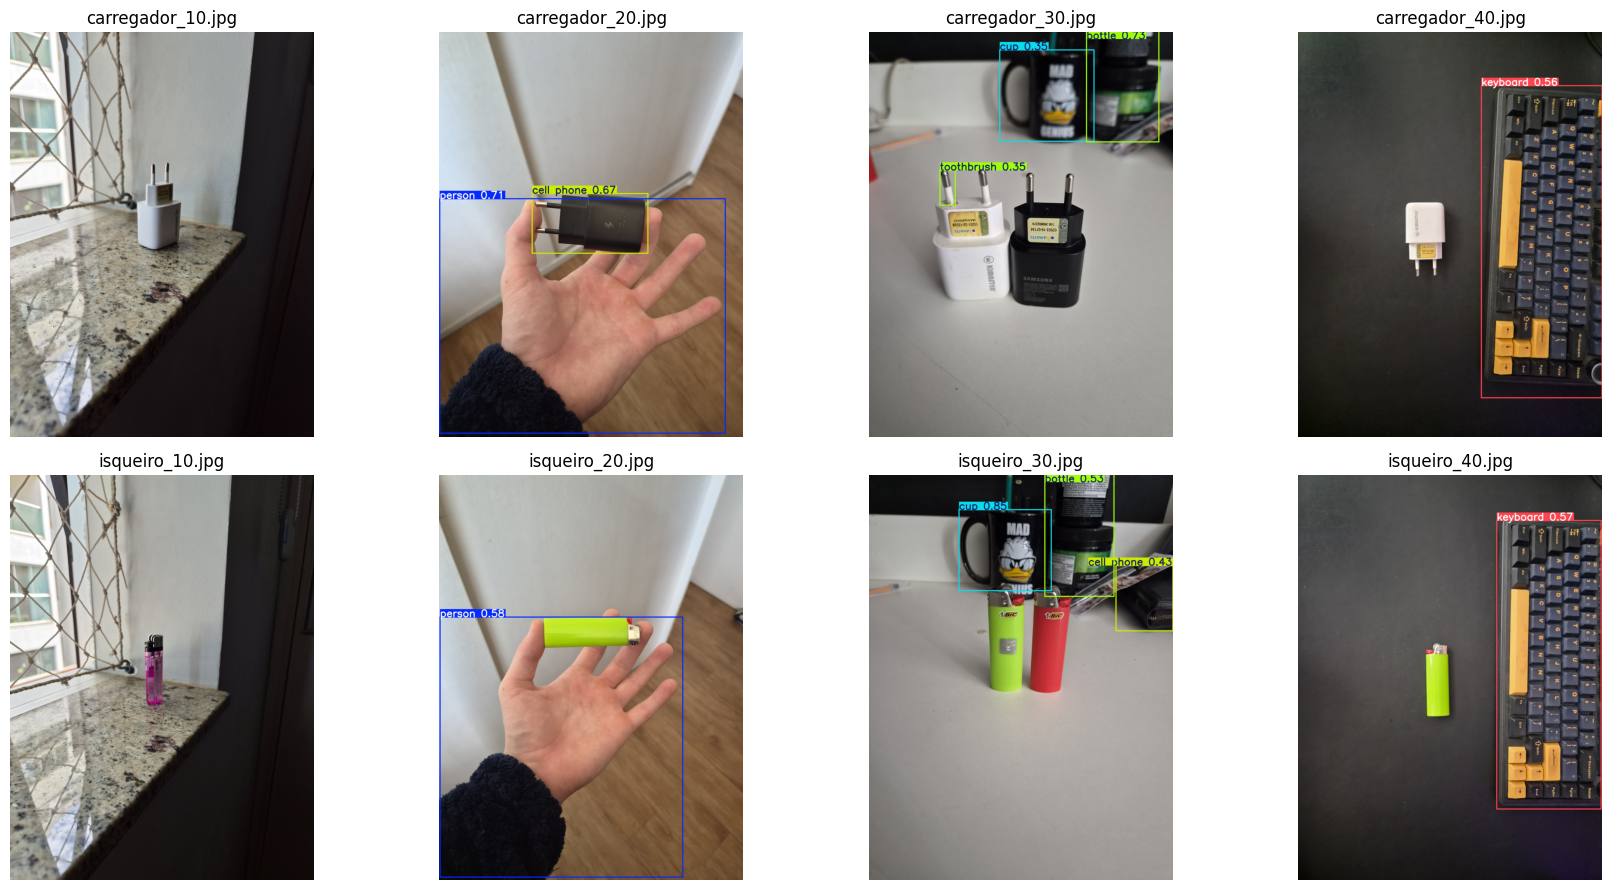

In [ ]:
# Mostra as 8 imagens de teste processadas pelo YOLO padrão
resultados = sorted(Path('runs/detect/test_padrao').glob('*.*'))

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, caminho in zip(axes.ravel(), resultados):
    ax.imshow(plt.imread(caminho))
    ax.set_title(caminho.name)
    ax.axis('off')
plt.tight_layout()
plt.show()

### Análise do YOLO padrão

| Imagem | O que o YOLO padrão detectou |
|---|---|
| carregador_10 | nada |
| carregador_20 | `person` (0,71) e `cell phone` (0,67) sobre o carregador |
| carregador_30 | `bottle` (0,73), `cup` (0,35) e `toothbrush` (0,35) sobre os pinos de um carregador |
| carregador_40 | `keyboard` (0,56) |
| isqueiro_10 | nada |
| isqueiro_20 | `person` (0,58) |
| isqueiro_30 | `cup` (0,85), `bottle` (0,53) e `cell phone` (0,43) |
| isqueiro_40 | `keyboard` (0,57) |

- **Objetos de interesse:** nenhum dos 10 foi identificado. Os 5 isqueiros foram
  ignorados. Dos 5 carregadores, 3 foram ignorados e 2 receberam rótulos errados
  (`cell phone` e `toothbrush`), as classes conhecidas mais parecidas.
- **O que ele acerta:** objetos do cenário que pertencem às 80 classes do COCO,
  como a mão (`person`), o teclado, a caneca e a garrafa. O modelo funciona, só
  não conhece os objetos deste projeto.
- **Risco:** o erro vem com confiança razoável (0,67 para `cell phone`). Sem
  conferência humana, o sistema informaria um objeto errado como se fosse certo.
- **Velocidade:** 15,8 ms de inferência por imagem, igual ao modelo customizado,
  já que a arquitetura é a mesma.
- **Conclusão:** o YOLO padrão é a opção mais fácil de usar, pois não exige
  dataset, rotulagem nem treino, mas só serve quando o objeto de interesse já
  está entre as classes conhecidas. Para objetos específicos do cliente, a
  customização da Entrega 1 é obrigatória.

## 10. CNN treinada do zero

Diferente do YOLO, a CNN faz **classificação**: recebe a imagem inteira e responde
apenas a qual classe ela pertence, sem localizar o objeto. Por isso não usa as
caixas rotuladas; a classe de cada imagem vem do nome do arquivo.

A rede não parte de pesos pré-treinados: todos os parâmetros são aprendidos com
as 64 imagens de treino. Arquitetura: três blocos de convolução e pooling,
seguidos de uma camada densa e de uma saída sigmoide (0 = isqueiro, 1 = carregador).

In [ ]:
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

TAM = 160  # lado, em pixels, das imagens de entrada da CNN

def carregar(split):
    """Lê as imagens de uma divisão e define a classe pelo nome do arquivo."""
    arquivos = sorted((BASE / 'images' / split).glob('*.jpg'))
    X = np.array([np.array(tf.keras.utils.load_img(a, target_size=(TAM, TAM)))
                  for a in arquivos], dtype='float32')
    y = np.array([0 if a.stem.startswith('isqueiro') else 1 for a in arquivos])
    return X, y, arquivos

X_train, y_train, _ = carregar('train')
X_val, y_val, _ = carregar('val')
X_test, y_test, arq_test = carregar('test')
print('treino:', X_train.shape, '| validação:', X_val.shape, '| teste:', X_test.shape)

treino: (64, 160, 160, 3) | validação: (8, 160, 160, 3) | teste: (8, 160, 160, 3)


In [ ]:
# Fixa a semente para reduzir a variação entre execuções
tf.keras.utils.set_random_seed(42)

L = tf.keras.layers
cnn = tf.keras.Sequential([
    L.Input((TAM, TAM, 3)),
    L.Rescaling(1 / 255),              # pixels de 0-255 para 0-1
    L.RandomFlip('horizontal'),        # aumento de dados: espelhamento
    L.RandomRotation(0.1),             # aumento de dados: rotação leve
    L.RandomZoom(0.1),                 # aumento de dados: zoom leve
    L.Conv2D(16, 3, activation='relu'), L.MaxPooling2D(),
    L.Conv2D(32, 3, activation='relu'), L.MaxPooling2D(),
    L.Conv2D(64, 3, activation='relu'), L.MaxPooling2D(),
    L.Flatten(),
    L.Dense(64, activation='relu'),
    L.Dropout(0.5),                    # reduz overfitting
    L.Dense(1, activation='sigmoid'),  # probabilidade de ser carregador
])
cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Treina por 60 épocas, mesmo número do melhor YOLO, medindo o tempo
inicio = time.time()
hist = cnn.fit(X_train, y_train, validation_data=(X_val, y_val),
               epochs=60, batch_size=16, verbose=0)
tempo_cnn = time.time() - inicio

print(f'Tempo de treino: {tempo_cnn:.1f} s')
print(f'Acurácia final no treino: {hist.history["accuracy"][-1]:.3f}')
print(f'Acurácia final na validação: {hist.history["val_accuracy"][-1]:.3f}')

Tempo de treino: 16.4 s
Acurácia final no treino: 1.000
Acurácia final na validação: 0.750


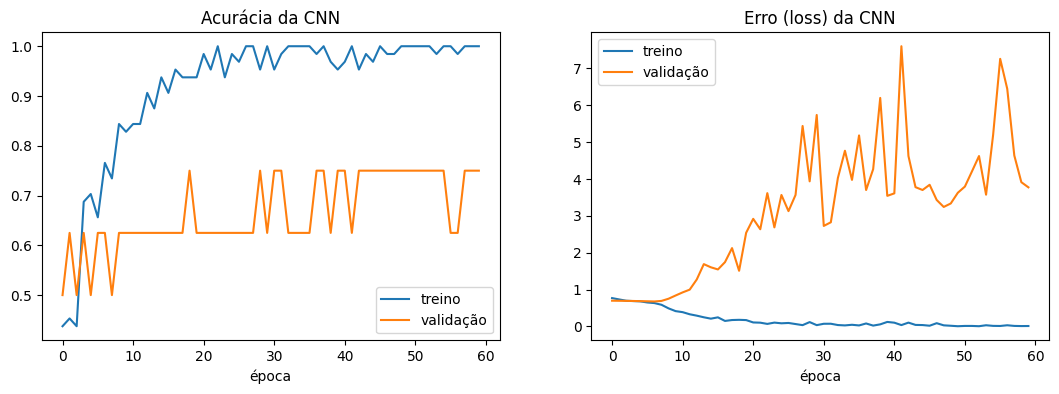

In [ ]:
# Curvas de acurácia e erro da CNN ao longo das épocas
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(hist.history['accuracy'], label='treino')
ax[0].plot(hist.history['val_accuracy'], label='validação')
ax[0].set_title('Acurácia da CNN')
ax[1].plot(hist.history['loss'], label='treino')
ax[1].plot(hist.history['val_loss'], label='validação')
ax[1].set_title('Erro (loss) da CNN')
for a in ax:
    a.set_xlabel('época')
    a.legend()
plt.show()

### Análise do treino da CNN

- **Overfitting:** a acurácia de treino chegou a 1,00, enquanto a de validação
  oscilou entre 0,625 e 0,75 (5 ou 6 acertos em 8 imagens) durante todo o treino.
- **Erro:** a perda de treino caiu para perto de zero, mas a de validação subiu
  de 0,7 para valores acima de 4 a partir da época 10. A rede passou a errar com
  confiança cada vez maior, sinal de que memorizou as imagens de treino.
- **Causa:** sem pesos pré-treinados, a rede precisa aprender do zero a enxergar
  bordas, texturas e formas com apenas 64 imagens. Além disso, o objeto ocupa uma
  parte pequena da foto, e a CNN classifica a imagem inteira, incluindo o fundo.
- **Tempo:** o treino levou 16,4 s, bem menos que os 3 min do YOLO, por ser uma
  rede muito menor e com imagens de 160 px.

### Teste da CNN

Acurácia no teste: 1.000 (8 de 8)
Tempo médio de inferência: 14.2 ms por imagem


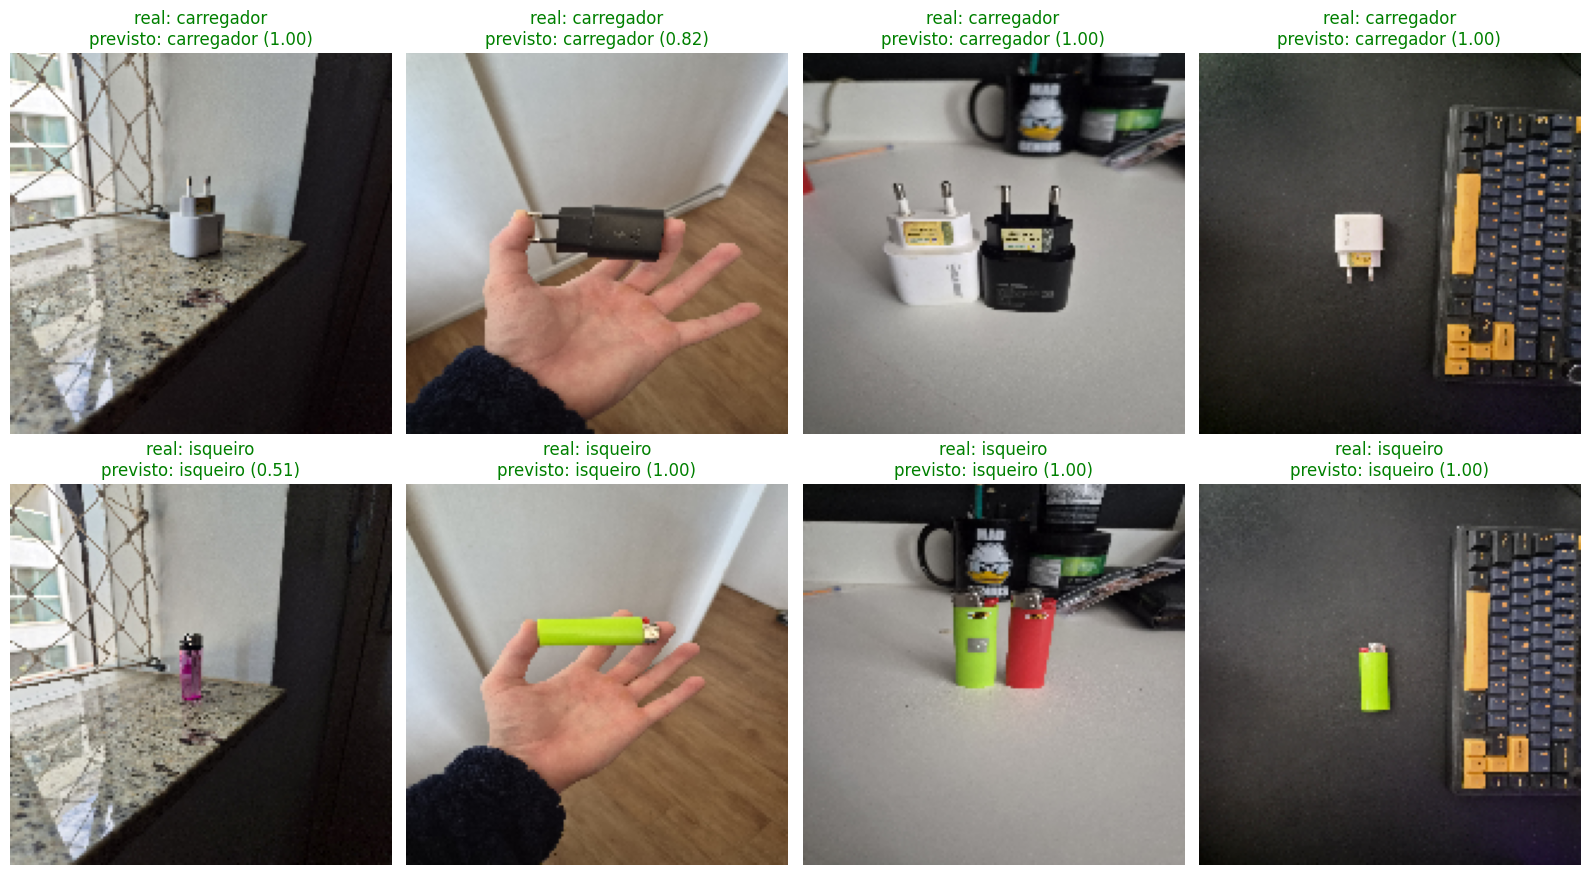

In [ ]:
CLASSES = ['isqueiro', 'carregador']

# Mede o tempo de inferência imagem a imagem (a primeira chamada é descartada como aquecimento)
cnn(X_test[:1], training=False)
tempos = []
for x in X_test:
    inicio = time.time()
    cnn(x[None], training=False)
    tempos.append(time.time() - inicio)
tempo_inf_cnn = np.mean(tempos) * 1000

# Previsões no conjunto de teste: probabilidade acima de 0,5 significa carregador
prob = cnn.predict(X_test, verbose=0).ravel()
pred = (prob > 0.5).astype(int)
acc_test = (pred == y_test).mean()

print(f'Acurácia no teste: {acc_test:.3f} ({(pred == y_test).sum()} de {len(y_test)})')
print(f'Tempo médio de inferência: {tempo_inf_cnn:.1f} ms por imagem')

# Mostra cada imagem de teste com a classe real e a prevista (verde = acerto, vermelho = erro)
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
for ax, img, real, p, pr in zip(axes.ravel(), X_test, y_test, pred, prob):
    confianca = pr if p == 1 else 1 - pr
    ax.imshow(img.astype('uint8'))
    ax.set_title(f'real: {CLASSES[real]}\nprevisto: {CLASSES[p]} ({confianca:.2f})',
                 color='green' if p == real else 'red')
    ax.axis('off')
plt.tight_layout()
plt.show()

### Análise do teste da CNN

- **Resultado:** 8 acertos em 8 imagens (acurácia de 1,00), com inferência de
  14,2 ms por imagem.
- **Validação x teste:** o resultado é melhor que o da validação (0,75) e não
  deve ser lido como prova de que o modelo é confiável. Com 8 imagens por
  conjunto, a diferença entre 6 e 8 acertos cabe na variação do acaso, e o
  histórico de treino mostra overfitting claro.
- **Confiança irregular:** seis imagens foram classificadas com confiança de
  1,00, mas o isqueiro na janela foi acertado com 0,51, no limite da decisão, e
  o carregador na mão com 0,82.
- **Hipótese sobre o que a rede aprendeu:** os isqueiros do dataset têm cores
  vivas (verde, vermelho, roxo) e os carregadores são brancos ou pretos. É
  provável que a CNN esteja se apoiando na cor, e não na forma. Isso explicaria
  a baixa confiança justamente no isqueiro mais escuro e menor na imagem. A
  hipótese não foi testada.
- **Limite da abordagem:** a CNN informa apenas a classe da imagem. Ela não
  localiza o objeto, não conta quantos existem e não lida com imagens que
  contenham os dois objetos ou nenhum deles.

## 11. Comparação das três abordagens

| Critério | YOLO customizado | YOLO padrão | CNN do zero |
|---|---|---|---|
| Tarefa | Detecção (classe e posição) | Detecção (classe e posição) | Classificação (só a classe) |
| Preparação dos dados | 80 imagens com caixas rotuladas à mão | Nenhuma | 80 imagens separadas por classe |
| Tempo de treino | 3 min 04 s (60 épocas) | Não se aplica | 16,4 s (60 épocas) |
| Resultado no teste | 10 de 10 objetos detectados, `mAP@0.5` de 0,995 | 0 de 10 objetos identificados | 8 de 8 imagens classificadas |
| Resultado na validação | `mAP@0.5` de 0,995, recall de 1,00 | Não se aplica | Acurácia de 0,75, com overfitting |
| Tempo de inferência | 14 a 18 ms por imagem | 15,8 ms por imagem | 1,6 ms por imagem (modelo compilado) |

### Avaliação crítica

- **Facilidade de uso e integração:** o YOLO padrão é o mais simples, pois roda
  com um único comando, sem dados nem treino. O YOLO customizado usa o mesmo
  comando de treino pronto, mas exige a etapa mais trabalhosa do projeto, que é
  rotular as caixas de cada imagem. A CNN dispensa as caixas, porém obriga a
  definir a arquitetura, o pré-processamento e os hiperparâmetros manualmente.
- **Precisão:** o YOLO customizado foi o único com bom resultado tanto na
  validação quanto no teste. O YOLO padrão falhou por completo nos objetos de
  interesse, por não conhecer as classes. A CNN acertou todo o teste, mas com
  overfitting evidente e validação de 0,75, o que torna o resultado pouco
  confiável. As métricas não são diretamente comparáveis: detectar e localizar
  um objeto é uma tarefa mais difícil do que classificar a imagem inteira.
- **Tempo de treinamento:** a CNN treina em segundos, por ser uma rede pequena
  com imagens de 160 px. O YOLO customizado leva cerca de 3 minutos, custo baixo
  graças aos pesos pré-treinados. O YOLO padrão não tem custo de treino.
- **Tempo de inferência:** os dois YOLO levam de 14 a 18 ms por imagem na GPU
  T4, mais 14 a 27 ms de pós-processamento das caixas. A CNN é cerca de dez
  vezes mais rápida, com 1,6 ms, por ser uma rede muito menor e operar em
  imagens de 160 px em vez de 640 px. Esse valor vem da medição com o modelo
  compilado, feita na seção 12; a medição inicial de 14,2 ms executava as
  camadas uma a uma e superestimava o tempo. Todas as abordagens são viáveis
  para tempo real.

### Conclusão

Não há uma abordagem melhor em todos os critérios. O **YOLO padrão** é a escolha
quando o objeto já pertence às 80 classes do COCO. A **CNN do zero** serve quando
basta saber a classe da imagem e há dados suficientes para evitar overfitting, o
que não é o caso com 64 imagens. Para o cenário do cliente, com objetos
específicos e necessidade de localizá-los, o **YOLO customizado** é a
recomendação: entrega a informação mais completa, com o resultado mais
consistente, ao custo de rotular as imagens.

**Limitação comum:** todos os resultados vêm de conjuntos de validação e teste
com 8 imagens, fotografadas nos mesmos ambientes do treino. As conclusões indicam
tendências, não medidas definitivas.

# Ir Além — Transfer Learning, Fine Tuning e segmentação

## 12. Transfer Learning com MobileNetV2

**Hipótese:** uma rede grande, pré-treinada em um conjunto imenso de imagens,
classifica melhor que uma arquitetura treinada do zero com 64 imagens?

**Arquitetura de referência:** MobileNetV2, pré-treinada na ImageNet (1,2 milhão
de imagens, 1.000 classes). Justificativa: é leve (cerca de 3,5 milhões de
parâmetros), rápida na inferência e pensada para dispositivos embarcados, o que
combina com aplicações de campo da FarmTech. Também tem pesos disponíveis para
entrada de 160 px, o mesmo tamanho usado na CNN do zero, o que deixa a comparação
justa.

**Pré-processamento extra:** a MobileNetV2 espera pixels entre -1 e 1, e não
entre 0 e 1 como na CNN do zero. A conversão é feita por uma camada `Rescaling`
dentro do próprio modelo.

**Estratégia em duas fases:**
1. **Transfer Learning:** toda a MobileNetV2 fica congelada e só a camada de
   saída é treinada, aproveitando as características já aprendidas na ImageNet.
2. **Fine Tuning:** as camadas a partir da 100 (de 154) são descongeladas e
   treinadas com taxa de aprendizado 100 vezes menor. As primeiras camadas
   detectam padrões genéricos (bordas, texturas), úteis para qualquer imagem, e
   ficam congeladas. As últimas são específicas das classes da ImageNet e são as
   que vale ajustar. Com apenas 64 imagens, descongelar a rede inteira levaria a
   overfitting.

In [ ]:
tf.keras.utils.set_random_seed(42)

# MobileNetV2 pré-treinada na ImageNet, sem a camada de classificação original
base = tf.keras.applications.MobileNetV2(input_shape=(TAM, TAM, 3),
                                         include_top=False, weights='imagenet')
base.trainable = False  # fase 1: toda a rede pré-treinada congelada

entrada = L.Input((TAM, TAM, 3))
x = L.RandomFlip('horizontal')(entrada)     # mesmo aumento de dados da CNN do zero
x = L.RandomRotation(0.1)(x)
x = L.RandomZoom(0.1)(x)
x = L.Rescaling(1 / 127.5, offset=-1)(x)    # pixels de 0-255 para -1 a 1
x = base(x, training=False)                 # mantém a normalização interna fixa
x = L.GlobalAveragePooling2D()(x)
x = L.Dropout(0.2)(x)
saida = L.Dense(1, activation='sigmoid')(x) # probabilidade de ser carregador
tl = tf.keras.Model(entrada, saida)

tl.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
           loss='binary_crossentropy', metrics=['accuracy'])

# Fase 1: treina só a camada de saída por 20 épocas
inicio = time.time()
hist_tl = tl.fit(X_train, y_train, validation_data=(X_val, y_val),
                 epochs=20, batch_size=16, verbose=0)
tempo_tl = time.time() - inicio

print(f'Tempo da fase 1: {tempo_tl:.1f} s')
print(f'Acurácia no treino: {hist_tl.history["accuracy"][-1]:.3f}')
print(f'Acurácia na validação: {hist_tl.history["val_accuracy"][-1]:.3f}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Tempo da fase 1: 10.5 s
Acurácia no treino: 1.000
Acurácia na validação: 0.750


In [ ]:
# Fase 2: descongela as camadas a partir da 100 e mantém as anteriores congeladas
base.trainable = True
for camada in base.layers[:100]:
    camada.trainable = False
print(f'Camadas da MobileNetV2: {len(base.layers)} | descongeladas: {len(base.layers) - 100}')

# Taxa de aprendizado 100 vezes menor, para ajustar os pesos sem destruí-los
tl.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
           loss='binary_crossentropy', metrics=['accuracy'])

inicio = time.time()
hist_ft = tl.fit(X_train, y_train, validation_data=(X_val, y_val),
                 epochs=20, batch_size=16, verbose=0)
tempo_ft = time.time() - inicio

print(f'Tempo da fase 2: {tempo_ft:.1f} s')
print(f'Acurácia no treino: {hist_ft.history["accuracy"][-1]:.3f}')
print(f'Acurácia na validação: {hist_ft.history["val_accuracy"][-1]:.3f}')

Camadas da MobileNetV2: 154 | descongeladas: 54
Tempo da fase 2: 18.6 s
Acurácia no treino: 1.000
Acurácia na validação: 0.875


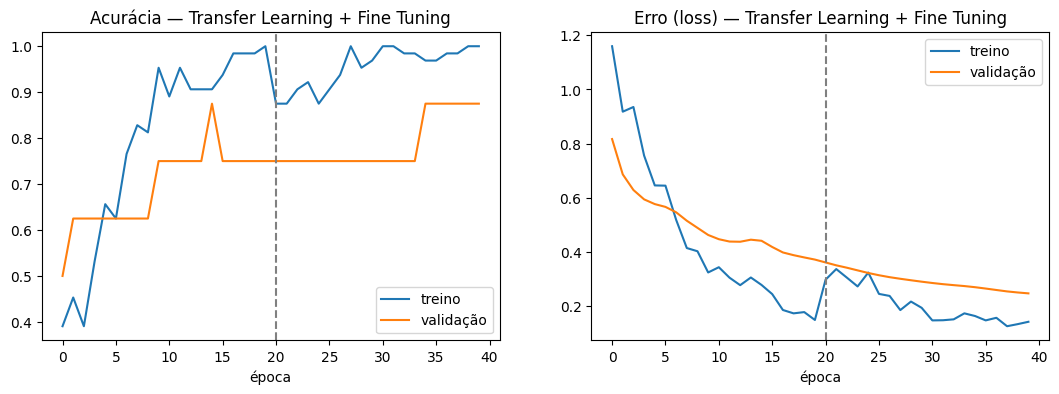

,imagem,CNN do zero,Transfer Learning
0,carregador_10.jpg,0.999,0.863
1,carregador_20.jpg,0.824,0.983
2,carregador_30.jpg,1.000,0.965
3,carregador_40.jpg,1.000,0.430
4,isqueiro_10.jpg,0.508,0.939
5,isqueiro_20.jpg,1.000,0.939
6,isqueiro_30.jpg,1.000,0.982
7,isqueiro_40.jpg,0.999,0.974


Acurácia no teste — CNN do zero: 1.000
Acurácia no teste — Transfer Learning: 0.875
Tempo de inferência do Transfer Learning: 266.8 ms por imagem


In [ ]:
import pandas as pd

# Curvas das duas fases em sequência (a linha tracejada marca o início do fine tuning)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for i, (chave, titulo) in enumerate([('accuracy', 'Acurácia'), ('loss', 'Erro (loss)')]):
    ax[i].plot(hist_tl.history[chave] + hist_ft.history[chave], label='treino')
    ax[i].plot(hist_tl.history['val_' + chave] + hist_ft.history['val_' + chave], label='validação')
    ax[i].axvline(20, color='gray', linestyle='--')
    ax[i].set_title(f'{titulo} — Transfer Learning + Fine Tuning')
    ax[i].set_xlabel('época')
    ax[i].legend()
plt.show()

# Tempo de inferência imagem a imagem (primeira chamada descartada como aquecimento)
tl(X_test[:1], training=False)
tempos = []
for x_img in X_test:
    inicio = time.time()
    tl(x_img[None], training=False)
    tempos.append(time.time() - inicio)
tempo_inf_tl = np.mean(tempos) * 1000

# Previsões da CNN do zero e do Transfer Learning nas mesmas imagens de teste
prob_cnn = cnn.predict(X_test, verbose=0).ravel()
prob_tl = tl.predict(X_test, verbose=0).ravel()

# Confiança atribuída à classe correta por cada modelo (acima de 0,5 = acerto)
comp_tl = pd.DataFrame({
    'imagem': [a.name for a in arq_test],
    'CNN do zero': np.where(y_test == 1, prob_cnn, 1 - prob_cnn),
    'Transfer Learning': np.where(y_test == 1, prob_tl, 1 - prob_tl),
}).round(3)
display(comp_tl)

print(f'Acurácia no teste — CNN do zero: {((prob_cnn > 0.5) == y_test).mean():.3f}')
print(f'Acurácia no teste — Transfer Learning: {((prob_tl > 0.5) == y_test).mean():.3f}')
print(f'Tempo de inferência do Transfer Learning: {tempo_inf_tl:.1f} ms por imagem')

In [ ]:
def medir_inferencia(modelo):
    """Tempo médio por imagem com o modelo compilado em grafo, como em uso real."""
    inferir = tf.function(lambda img: modelo(img, training=False))
    inferir(tf.constant(X_test[:1]))  # aquecimento: compila o grafo
    tempos = []
    for x_img in X_test:
        inicio = time.time()
        inferir(tf.constant(x_img[None])).numpy()
        tempos.append(time.time() - inicio)
    return np.mean(tempos) * 1000

tempo_grafo_cnn = medir_inferencia(cnn)
tempo_grafo_tl = medir_inferencia(tl)
print(f'Inferência compilada — CNN do zero: {tempo_grafo_cnn:.1f} ms por imagem')
print(f'Inferência compilada — Transfer Learning: {tempo_grafo_tl:.1f} ms por imagem')

Inferência compilada — CNN do zero: 1.6 ms por imagem
Inferência compilada — Transfer Learning: 6.6 ms por imagem


### Análise do Transfer Learning

| Métrica | CNN do zero | Transfer Learning + Fine Tuning |
|---|---|---|
| Acurácia na validação | 0,750 | 0,875 |
| Erro (loss) final na validação | acima de 3 | cerca de 0,25 |
| Acurácia no teste | 1,000 (8 de 8) | 0,875 (7 de 8) |
| Tempo de treino | 16,4 s | 29,1 s (10,5 s + 18,6 s) |
| Inferência (modelo compilado) | 1,6 ms | 6,6 ms |

- **Hipótese:** confirmada em parte. A rede pré-treinada generaliza melhor: a
  perda de validação cai de forma contínua até 0,25, enquanto a da CNN do zero
  explodiu para mais de 3, e a acurácia de validação subiu de 0,75 para 0,875.
  No teste, porém, ela acertou uma imagem a menos. Com 8 imagens, cada uma vale
  12,5 pontos, então a diferença de acurácia não é conclusiva. O que os dados
  sustentam é que o Transfer Learning não sofreu o overfitting da CNN do zero.
- **Efeito do Fine Tuning:** a validação passou de 0,75 na fase 1 para 0,875 na
  fase 2, com a perda continuando a cair. A queda momentânea da acurácia de
  treino no início da fase 2 é o ajuste inicial das camadas descongeladas.
- **Confiança mais realista:** a CNN do zero responde com confiança de 1,00 em
  quase tudo, inclusive enquanto seu erro de validação crescia. O Transfer
  Learning fica entre 0,86 e 0,98 nos acertos. No isqueiro da janela, a CNN
  acertou no limite (0,51) e o Transfer Learning com folga (0,94).
- **O erro:** o `carregador_40` (confiança de 0,43) é a foto do carregador
  pequeno ao lado do teclado. A foto do isqueiro no mesmo cenário foi
  classificada como isqueiro com 0,97. Isso sugere que a rede está sendo
  influenciada pelo fundo, que ocupa a maior parte da imagem, e não só pelo
  objeto. A segmentação da próxima seção testa exatamente essa hipótese.
- **Custo:** o treino leva quase o dobro do tempo e a inferência é quatro vezes
  mais lenta (6,6 ms contra 1,6 ms), ainda muito abaixo do necessário para tempo
  real. O valor de 266,8 ms impresso junto com a tabela acima não representa o custo
  da rede: aquela medição executa as 154 camadas uma a uma, e a medição com o
  modelo compilado é a correta.

## 13. Segmentação do objeto e recorte do fundo

**Hipótese:** pré-segmentar o objeto de interesse, informando à rede quais pixels
devem ser considerados, facilita a classificação da imagem?

**Rede de segmentação:** U²-Net, pela biblioteca `rembg`. É uma rede de detecção
de objeto saliente: separa o elemento em destaque do fundo sem depender de
classe. A escolha se justifica porque redes de segmentação tradicionais só
reconhecem as classes em que foram treinadas, e os objetos deste projeto não
estão entre elas. As máscaras são geradas de forma automática, sem marcação manual.

**Processo:**
1. a U²-Net gera uma máscara para cada imagem (branco = objeto, preto = fundo);
2. a máscara é aplicada sobre a imagem original, apagando o fundo (pixels pretos);
3. a rede de classificação é treinada e testada com as imagens recortadas, e o
   resultado é comparado com o obtido nas imagens originais.

In [ ]:
# Instala a biblioteca de segmentação (U²-Net)
!pip install -q "rembg[cpu]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 98.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 MB 11.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.3 requires numba<=0.65.1,>=0.58, but you have numba 0.68.0 which is incompatible.
cudf-cu13 26.6.0 requires numba<0.65.0,>=0.60.0, but you have numba 0.68.0 which is incompatible.
cuml-

In [ ]:
from PIL import Image, ImageOps
from rembg import new_session, remove

# Carrega a U²-Net uma única vez para reutilizar em todas as imagens
sessao = new_session('u2net')

def segmentar(caminho):
    """Devolve a imagem original, a máscara e a imagem com o fundo apagado."""
    img = ImageOps.exif_transpose(Image.open(caminho)).convert('RGB')
    img.thumbnail((640, 640))                               # reduz para acelerar
    mascara = remove(img, session=sessao, only_mask=True)   # 0 = fundo, 255 = objeto
    original = np.array(img)
    mascara = np.array(mascara) > 127                       # máscara binária
    recorte = original * mascara[..., None]                 # fundo vira preto
    return original, mascara, recorte

def carregar_segmentado(arquivos):
    """Segmenta uma lista de imagens e devolve os recortes no tamanho da rede."""
    return np.array([np.array(Image.fromarray(segmentar(a)[2]).resize((TAM, TAM)))
                     for a in arquivos], dtype='float32')

# Segmenta as 80 imagens (leva alguns minutos, pois roda em CPU)
inicio = time.time()
Xs_train = carregar_segmentado(sorted((BASE / 'images' / 'train').glob('*.jpg')))
Xs_val = carregar_segmentado(sorted((BASE / 'images' / 'val').glob('*.jpg')))
Xs_test = carregar_segmentado(arq_test)
tempo_seg = time.time() - inicio

print('treino:', Xs_train.shape, '| validação:', Xs_val.shape, '| teste:', Xs_test.shape)
print(f'Tempo de segmentação: {tempo_seg:.0f} s para 80 imagens '
      f'({tempo_seg / 80 * 1000:.0f} ms por imagem)')

treino: (64, 160, 160, 3) | validação: (8, 160, 160, 3) | teste: (8, 160, 160, 3)
Tempo de segmentação: 128 s para 80 imagens (1601 ms por imagem)


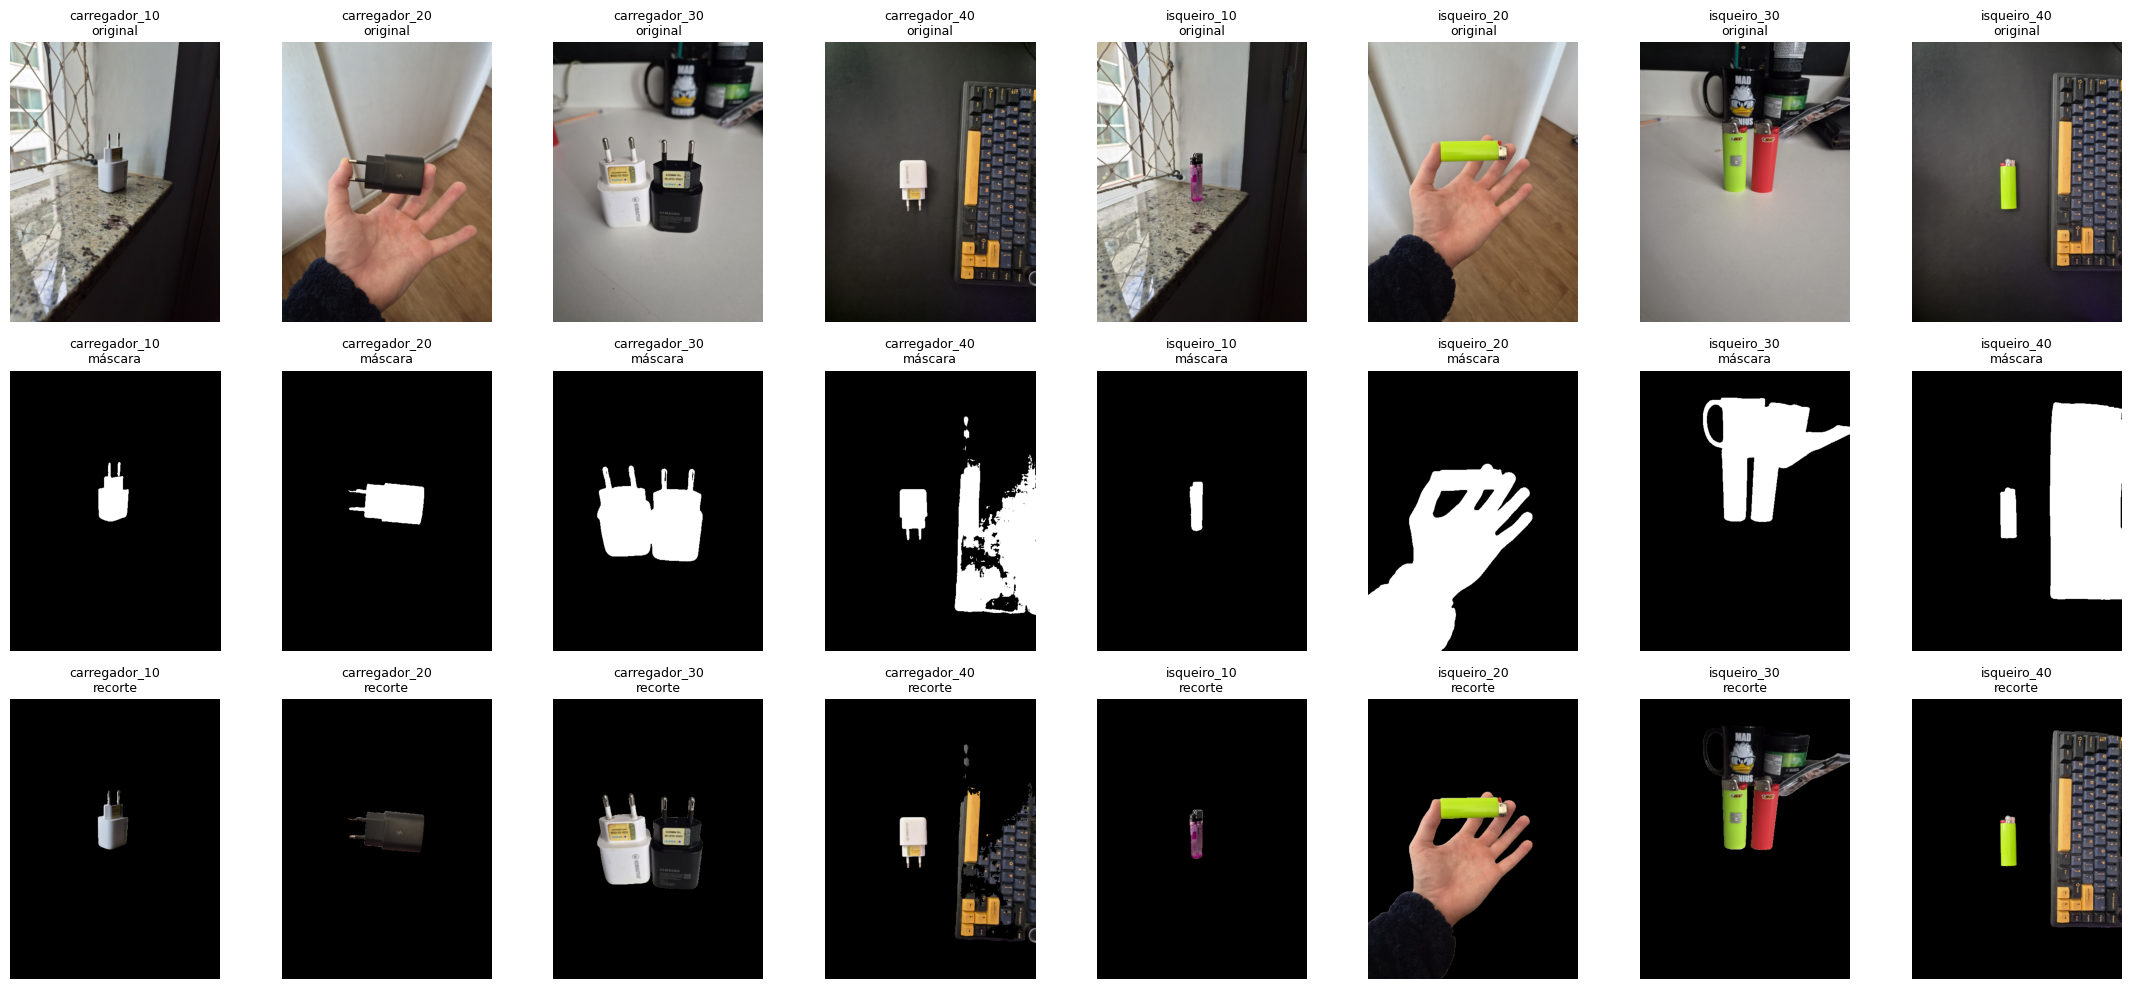

In [ ]:
# Original, máscara e recorte das 8 imagens de teste
fig, axes = plt.subplots(3, 8, figsize=(22, 10))
for coluna, caminho in enumerate(arq_test):
    original, mascara, recorte = segmentar(caminho)
    for linha, (img, nome) in enumerate([(original, 'original'), (mascara, 'máscara'), (recorte, 'recorte')]):
        axes[linha, coluna].imshow(img, cmap='gray')
        axes[linha, coluna].set_title(f'{caminho.stem}\n{nome}', fontsize=9)
        axes[linha, coluna].axis('off')
plt.tight_layout()
plt.show()

### Análise das máscaras

- **Máscaras limpas (4 de 8):** nas imagens `carregador_10`, `carregador_20`,
  `carregador_30` e `isqueiro_10`, a U²-Net isolou apenas o objeto. Na
  `carregador_20`, separou o carregador da mão que o segura.
- **Máscaras com fundo (4 de 8):** na `isqueiro_20`, a mão inteira entrou na
  máscara; na `isqueiro_30`, a caneca e outros itens da mesa; na `isqueiro_40`,
  o teclado inteiro; na `carregador_40`, parte do teclado, com ruído.
- **Causa:** a U²-Net segmenta o que é visualmente saliente, sem saber qual é o
  objeto de interesse. Quando há outro elemento em destaque na cena, ele é
  incluído. Uma segmentação guiada pelas caixas do YOLO customizado resolveria
  esse ponto, e fica como melhoria futura.
- **Custo:** a segmentação levou 128 s para as 80 imagens, cerca de 1,6 s por
  imagem em CPU. É a etapa mais lenta de todo o projeto, centenas de vezes mais
  demorada que a classificação.

### Classificação com as imagens recortadas

Os dois classificadores são treinados novamente, com a mesma arquitetura e os
mesmos parâmetros, usando as imagens recortadas no treino, na validação e no teste.

In [ ]:
tf.keras.utils.set_random_seed(42)

# CNN do zero: mesma arquitetura da seção 10, com pesos reiniciados
cnn_seg = tf.keras.models.clone_model(cnn)
cnn_seg.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_seg.fit(Xs_train, y_train, validation_data=(Xs_val, y_val),
            epochs=60, batch_size=16, verbose=0)

# Transfer Learning: mesma receita da seção 12
base_seg = tf.keras.applications.MobileNetV2(input_shape=(TAM, TAM, 3),
                                             include_top=False, weights='imagenet')
base_seg.trainable = False
entrada = L.Input((TAM, TAM, 3))
x = L.RandomFlip('horizontal')(entrada)
x = L.RandomRotation(0.1)(x)
x = L.RandomZoom(0.1)(x)
x = L.Rescaling(1 / 127.5, offset=-1)(x)
x = base_seg(x, training=False)
x = L.GlobalAveragePooling2D()(x)
x = L.Dropout(0.2)(x)
tl_seg = tf.keras.Model(entrada, L.Dense(1, activation='sigmoid')(x))

# Fase 1: só a camada de saída
tl_seg.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
               loss='binary_crossentropy', metrics=['accuracy'])
tl_seg.fit(Xs_train, y_train, validation_data=(Xs_val, y_val),
           epochs=20, batch_size=16, verbose=0)

# Fase 2: fine tuning das camadas a partir da 100
base_seg.trainable = True
for camada in base_seg.layers[:100]:
    camada.trainable = False
tl_seg.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
               loss='binary_crossentropy', metrics=['accuracy'])
tl_seg.fit(Xs_train, y_train, validation_data=(Xs_val, y_val),
           epochs=20, batch_size=16, verbose=0)
print('Treinos concluídos.')

Treinos concluídos.


In [ ]:
# Erro e acurácia de cada modelo, nas imagens originais e nas recortadas
modelos = [('CNN do zero — original', cnn, X_val, X_test),
           ('CNN do zero — recortada', cnn_seg, Xs_val, Xs_test),
           ('Transfer Learning — original', tl, X_val, X_test),
           ('Transfer Learning — recortada', tl_seg, Xs_val, Xs_test)]

linhas, confiancas = [], {'imagem': [a.name for a in arq_test]}
for nome, modelo, Xv, Xt in modelos:
    loss_val, acc_val = modelo.evaluate(Xv, y_val, verbose=0)
    loss_test, acc_test = modelo.evaluate(Xt, y_test, verbose=0)
    linhas.append({'modelo': nome, 'loss validação': loss_val, 'acurácia validação': acc_val,
                   'loss teste': loss_test, 'acurácia teste': acc_test})
    # Confiança atribuída à classe correta em cada imagem de teste
    p = modelo.predict(Xt, verbose=0).ravel()
    confiancas[nome] = np.where(y_test == 1, p, 1 - p)

display(pd.DataFrame(linhas).set_index('modelo').round(3))
display(pd.DataFrame(confiancas).round(3))

,loss validação,acurácia validação,loss teste,acurácia teste
modelo,,,,
CNN do zero — original,3.771,0.750,0.109,1.000
CNN do zero — recortada,0.164,0.875,0.003,1.000
Transfer Learning — original,0.247,0.875,0.152,0.875
Transfer Learning — recortada,0.031,1.000,0.138,1.000


,imagem,CNN do zero — original,CNN do zero — recortada,Transfer Learning — original,Transfer Learning — recortada
0,carregador_10.jpg,0.999,0.998,0.863,0.957
1,carregador_20.jpg,0.824,0.991,0.983,0.975
2,carregador_30.jpg,1.000,1.000,0.965,0.997
3,carregador_40.jpg,1.000,1.000,0.430,0.966
4,isqueiro_10.jpg,0.508,0.991,0.939,0.871
5,isqueiro_20.jpg,1.000,1.000,0.939,0.572
6,isqueiro_30.jpg,1.000,1.000,0.982,0.969
7,isqueiro_40.jpg,0.999,1.000,0.974,0.763


### Análise da classificação com imagens recortadas

| Modelo | Loss validação | Acurácia validação | Acurácia teste |
|---|---|---|---|
| CNN do zero — original | 3,771 | 0,750 | 1,000 |
| CNN do zero — recortada | 0,164 | 0,875 | 1,000 |
| Transfer Learning — original | 0,247 | 0,875 | 0,875 |
| Transfer Learning — recortada | 0,031 | 1,000 | 1,000 |

- **Hipótese:** confirmada nestes dados. Com o fundo apagado, os dois modelos
  melhoraram na validação (CNN de 0,75 para 0,875; Transfer Learning de 0,875
  para 1,00) e o erro de validação caiu muito: 23 vezes na CNN e 8 vezes no
  Transfer Learning.
- **CNN do zero:** foi a mais beneficiada. O overfitting observado na seção 10
  praticamente desapareceu (loss de validação de 3,77 para 0,16). Sem o fundo, a
  rede tem menos pixels irrelevantes para memorizar. O isqueiro da janela, antes
  acertado no limite (0,51), passou a 0,99.
- **Transfer Learning:** corrigiu o único erro do teste. O `carregador_40` foi
  de 0,43 para 0,97, o que confirma a suspeita da seção 12 de que o teclado ao
  fundo estava atrapalhando a classificação.
- **A qualidade da máscara importa:** nas duas imagens em que a máscara incluiu
  outros elementos, a confiança do Transfer Learning caiu: `isqueiro_20` (mão na
  máscara) de 0,94 para 0,57 e `isqueiro_40` (teclado na máscara) de 0,97 para
  0,76. Os acertos se mantiveram, mas com menos margem. Segmentação ruim pode
  prejudicar em vez de ajudar.
- **Custo:** a segmentação leva cerca de 1,6 s por imagem em CPU, contra 1,6 a
  6,6 ms da classificação. O ganho de acurácia custa a perda do tempo real, a
  menos que a segmentação rode em GPU ou com uma rede mais leve.
- **Ressalva:** os resultados vêm de uma única execução, com 8 imagens de
  validação e 8 de teste.

## 14. Conclusões do Ir Além

- **Transfer Learning x CNN do zero:** a rede pré-treinada generalizou melhor,
  sem o overfitting da CNN do zero, ao custo de treino e inferência mais lentos.
  A vantagem em acurácia não ficou comprovada no teste com imagens originais.
- **Com segmentação x sem segmentação:** apagar o fundo ajudou os dois modelos.
  A melhor combinação foi Transfer Learning com imagens recortadas: acurácia de
  1,00 em validação e teste e o menor erro de validação (0,031).
- **Justificativa crítica:** o fundo era o principal problema da classificação
  neste dataset. Os objetos ocupam uma parte pequena das fotos, e os mesmos
  cenários aparecem nas duas classes, então a rede aprende com facilidade
  detalhes do ambiente em vez do objeto. A segmentação ataca esse problema na
  origem, mas depende de uma máscara correta.
- **Limitações:** a U²-Net não sabe qual é o objeto de interesse e incluiu mão,
  caneca e teclado em metade das máscaras de teste; a segmentação é lenta em
  CPU; e os conjuntos de avaliação são pequenos.
- **Próximos passos:** usar as caixas do YOLO customizado da Entrega 1 para
  recortar a região do objeto antes de segmentar, o que eliminaria os elementos
  indevidos da máscara, e repetir os experimentos com mais imagens.

## 15. Figura explicativa do Ir Além

O diagrama resume as duas abordagens comparadas nas seções 12 e 13. Na primeira,
a imagem original vai direto para o classificador. Na segunda, a U²-Net gera uma
máscara, o fundo é apagado e só então a imagem é classificada.

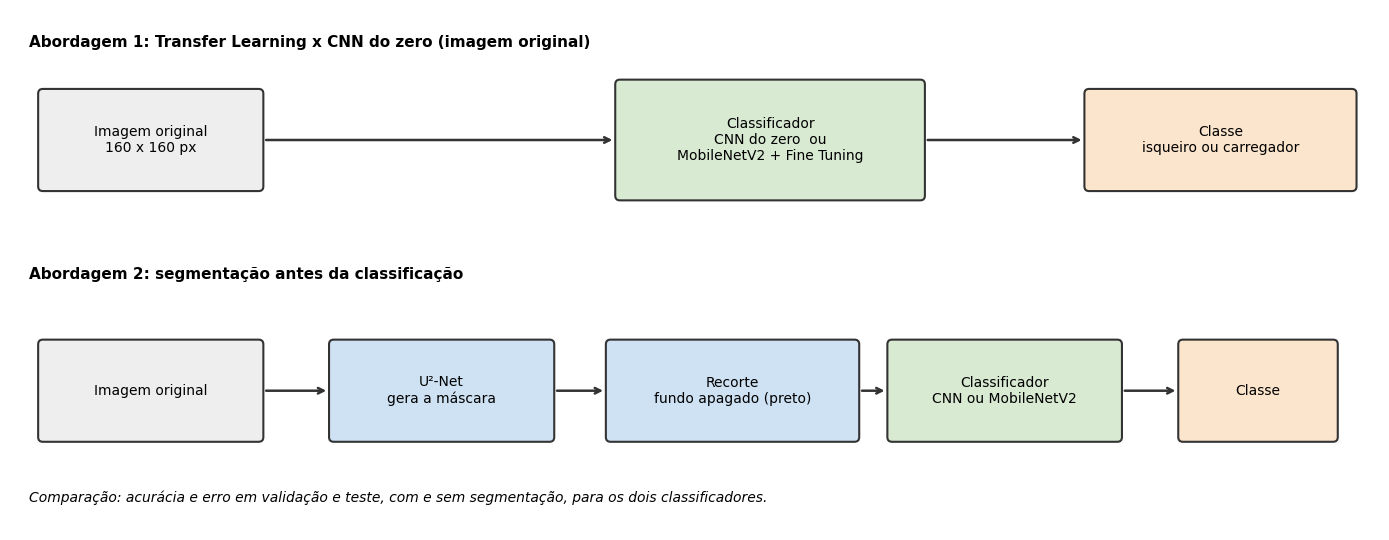

In [ ]:
from matplotlib.patches import FancyBboxPatch

def caixa(ax, x, y, texto, cor, w=2.3, h=1.0):
    """Desenha uma caixa com texto centralizado em (x, y)."""
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h,
                                boxstyle='round,pad=0.05', fc=cor, ec='#333333', lw=1.5))
    ax.text(x, y, texto, ha='center', va='center', fontsize=10)

def seta(ax, x1, y1, x2, y2):
    """Desenha uma seta entre dois pontos."""
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', lw=1.8, color='#333333'))

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.set_xlim(0, 14.6)
ax.set_ylim(0, 5.6)
ax.axis('off')

AZUL, VERDE, LARANJA, CINZA = '#cfe2f3', '#d9ead3', '#fce5cd', '#eeeeee'

# Abordagem 1: classificação direta da imagem original
ax.text(0.2, 5.2, 'Abordagem 1: Transfer Learning x CNN do zero (imagem original)',
        fontsize=11, fontweight='bold')
caixa(ax, 1.5, 4.2, 'Imagem original\n160 x 160 px', CINZA)
caixa(ax, 8.1, 4.2, 'Classificador\nCNN do zero  ou\nMobileNetV2 + Fine Tuning', VERDE, w=3.2, h=1.2)
caixa(ax, 12.9, 4.2, 'Classe\nisqueiro ou carregador', LARANJA, w=2.8)
seta(ax, 2.7, 4.2, 6.45, 4.2)
seta(ax, 9.75, 4.2, 11.45, 4.2)

# Abordagem 2: segmentação antes da classificação
ax.text(0.2, 2.7, 'Abordagem 2: segmentação antes da classificação',
        fontsize=11, fontweight='bold')
caixa(ax, 1.5, 1.5, 'Imagem original', CINZA)
caixa(ax, 4.6, 1.5, 'U²-Net\ngera a máscara', AZUL)
caixa(ax, 7.7, 1.5, 'Recorte\nfundo apagado (preto)', AZUL, w=2.6)
caixa(ax, 10.6, 1.5, 'Classificador\nCNN ou MobileNetV2', VERDE, w=2.4)
caixa(ax, 13.3, 1.5, 'Classe', LARANJA, w=1.6)
seta(ax, 2.7, 1.5, 3.4, 1.5)
seta(ax, 5.8, 1.5, 6.35, 1.5)
seta(ax, 9.05, 1.5, 9.35, 1.5)
seta(ax, 11.85, 1.5, 12.45, 1.5)

ax.text(0.2, 0.3, 'Comparação: acurácia e erro em validação e teste, com e sem '
        'segmentação, para os dois classificadores.', fontsize=10, style='italic')
plt.tight_layout()
plt.show()